# 📱 End-To-End SMS Spam Detector
### Using Machine Learning Algorithms

---

## 🗂️ Project Overview

This notebook builds a complete **SMS Spam Detection** system from raw data to a deployable model. The goal is to classify SMS messages as **Ham (legitimate)** or **Spam** using Natural Language Processing and Machine Learning.

### 📋 Pipeline
| Step | Description |
|------|-------------|
| 1️⃣ Data Cleaning | Handle missing values, duplicates, and irrelevant columns |
| 2️⃣ EDA | Explore distributions and visualize patterns |
| 3️⃣ Text Preprocessing | Tokenize, remove stopwords, stem |
| 4️⃣ Feature Engineering | TF-IDF vectorization |
| 5️⃣ Model Building | Train and compare 10 classifiers |
| 6️⃣ Evaluation | Confusion matrix + Classification report |
| 7️⃣ Prediction | Predict on unseen test data |
| 8️⃣ Deployment | Save model with Pickle |

---
## 📦 1. Import Libraries

In [42]:
# ── Core Libraries ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# ── NLP ────────────────────────────────────────────────────────────
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# ── ML & Preprocessing ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Classifiers ────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# ── Evaluation ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# ── Deployment ─────────────────────────────────────────────────────
import pickle

# ── Plot Style ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14})

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


---
##  2. Load Dataset


> 📌 **Source:** [Kaggle – SMS Spam Collection Dataset](https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset)

In [43]:
df = pd.read_csv('emails.csv', encoding='latin-1')

print(f' Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.sample(5)

 Dataset shape: 5728 rows × 2 columns


,text,spam
1343,Subject: capital hill gold - chgi - potential ...,1
1164,Subject: very uuseful attache how to save on ...,1
1520,Subject: re : pending approval for ibuyit requ...,0
3915,Subject: re : energy derivatives conference - ...,0
3052,"Subject: re : jaesoo lew vince , we should st...",0


---
##  3. Data Cleaning


In [44]:
# ── Step 1: Inspect raw data ───────────────────────────────────────
print(' Dataset Info:')
df.info()

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [ ]:
# ── Step 2: Rename columns for clarity ────────────────────────────
df = df.rename(columns={'spam': 'target'})

print(' Columns after cleaning:', df.columns.tolist())
df.sample(5)

 Columns after cleaning: ['text', 'target']


,text,target
4896,"Subject: re : chapter chris , my part has no...",0
2317,Subject: re : edith terry vince : thank you ...,0
4438,"Subject: re : returning you call celeste , w...",0
3514,"Subject: review of paper by titman , et al re...",0
232,"Subject: re : protect your computer , you need...",1


In [46]:

# 'ham' → 0  |  'spam' → 1

print(' Label encoding: ham=0, spam=1')
print(df['target'].value_counts())

 Label encoding: ham=0, spam=1
target
0    4360
1    1368
Name: count, dtype: int64


In [47]:
# ── Step 3: Check missing values ──────────────────────────────────
missing = df.isnull().sum()
print(' Missing values per column:')
print(missing)
print(f'\n No missing values!' if missing.sum() == 0 else f'\n  Found {missing.sum()} missing values.')

 Missing values per column:
text      0
target    0
dtype: int64

 No missing values!


In [48]:
# ── Step 4: Handle duplicates ──────────────────────────────────────
before = df.shape[0]
df = df.drop_duplicates()   # keep='first' by default
after = df.shape[0]

print(f' Removed {before - after} duplicate rows.')
print(f' Dataset shape after cleaning: {df.shape[0]} rows × {df.shape[1]} columns')

 Removed 33 duplicate rows.
 Dataset shape after cleaning: 5695 rows × 2 columns


---
##  4. Exploratory Data Analysis (EDA)
 explore the class distribution, message length statistics, and word-level patterns to better understand how spam and ham messages differ.

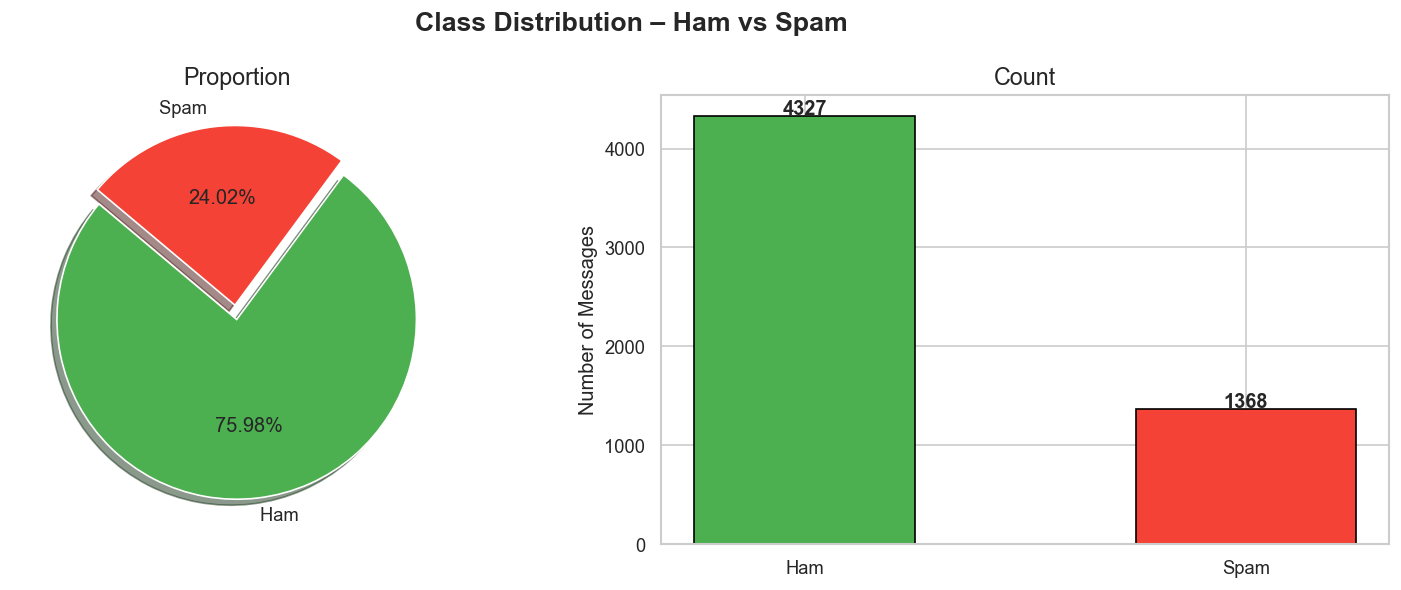

  The dataset is imbalanced — spam messages are ~24% of the total.
  handle this with SMOTE during model training.


In [50]:
# ── Class distribution ────────────────────────────────────────────
counts = df['target'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Distribution – Ham vs Spam', fontsize=16, fontweight='bold')

# Pie chart
axes[0].pie(
    counts,
    labels=['Ham ', 'Spam '],
    autopct='%1.2f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=140,
    explode=(0, 0.08),
    shadow=True
)
axes[0].set_title('Proportion')

# Bar chart
axes[1].bar(['Ham', 'Spam'], counts.values, color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
axes[1].set_title('Count')
axes[1].set_ylabel('Number of Messages')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 15, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print('  The dataset is imbalanced — spam messages are ~24% of the total.')
print('  handle this with SMOTE during model training.')

In [51]:
# ── Feature Engineering for EDA ────────────────────────────────────
# Number of characters, words, and sentences per message
df['num_characters'] = df['text'].apply(len)
df['num_words']      = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences']  = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

print(' Overall statistics:')
df[['num_characters', 'num_words', 'num_sentences']].describe().round(2)

 Overall statistics:


,num_characters,num_words,num_sentences
count,5695.00,5695.00,5695.00
mean,1558.07,328.21,19.46
std,2047.08,419.65,35.98
min,13.00,3.00,1.00
25%,508.50,102.00,7.00
50%,979.00,211.00,12.00
75%,1893.00,403.00,22.00
max,43952.00,8479.00,1565.00


In [52]:
# ── Stats split by class ───────────────────────────────────────────
print(' HAM message statistics:')
display(df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe().round(2))

print('\n SPAM message statistics:')
display(df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe().round(2))

print('\n Observation: Spam messages are notably longer in characters, words, and sentences.')

 HAM message statistics:


,num_characters,num_words,num_sentences
count,4327.00,4327.00,4327.00
mean,1634.20,347.28,19.84
std,1965.02,407.23,38.12
min,13.00,3.00,1.00
25%,577.50,120.00,7.00
50%,1122.00,240.00,13.00
75%,2037.50,440.50,22.00
max,43952.00,8479.00,1565.00



 SPAM message statistics:


,num_characters,num_words,num_sentences
count,1368.00,1368.00,1368.00
mean,1317.26,267.90,18.27
std,2271.37,451.62,28.13
min,18.00,5.00,1.00
25%,401.50,80.00,6.00
50%,693.50,141.00,11.00
75%,1250.25,252.00,18.00
max,28432.00,6131.00,438.00



 Observation: Spam messages are notably longer in characters, words, and sentences.


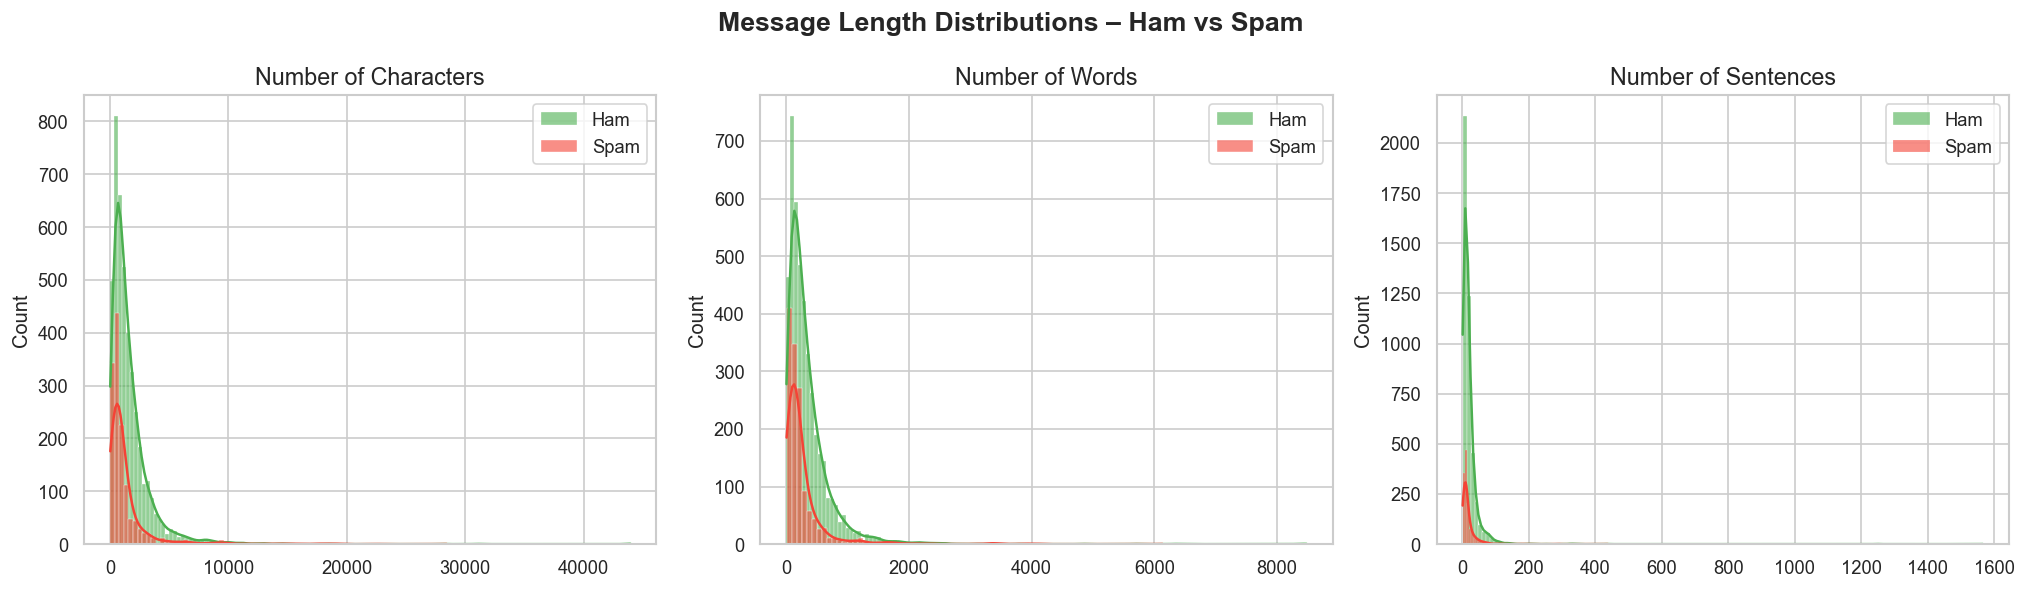

In [53]:
# ── Distribution plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Message Length Distributions – Ham vs Spam', fontsize=16, fontweight='bold')

features   = ['num_characters', 'num_words', 'num_sentences']
feat_names = ['Number of Characters', 'Number of Words', 'Number of Sentences']

for ax, feat, name in zip(axes, features, feat_names):
    sns.histplot(df[df['target'] == 0][feat], ax=ax, color='#4CAF50', label='Ham', kde=True, alpha=0.6)
    sns.histplot(df[df['target'] == 1][feat], ax=ax, color='#F44336', label='Spam', kde=True, alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('')
    ax.legend()

plt.tight_layout()
plt.show()

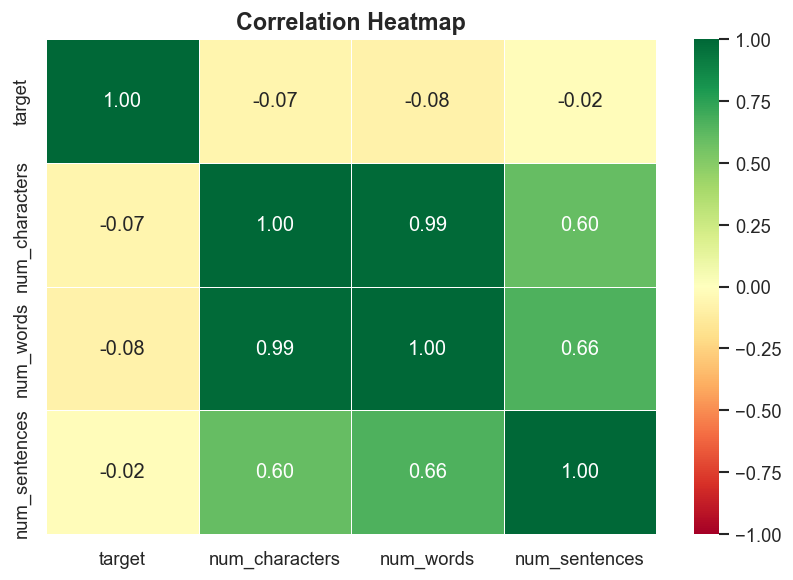

In [54]:
# ── Correlation heatmap ───────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(),
    annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


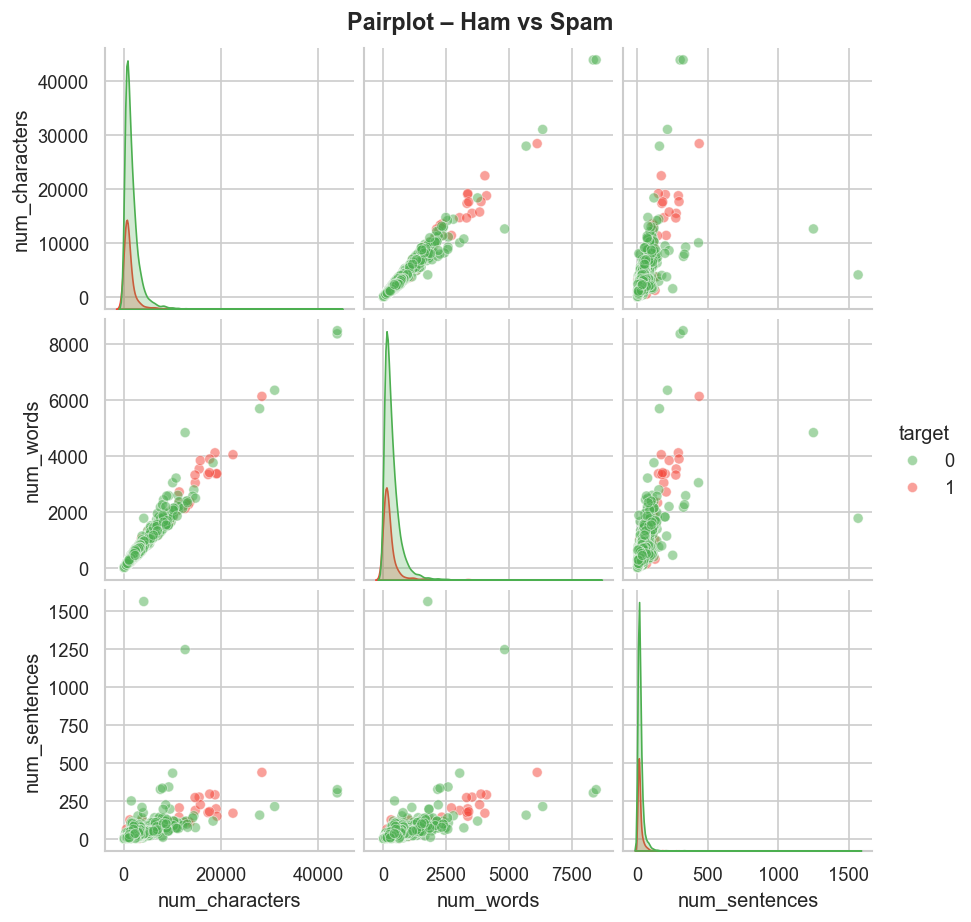

In [55]:
# ── Pairplot ──────────────────────────────────────────────────────
sns.pairplot(
    df[['target', 'num_characters', 'num_words', 'num_sentences']],
    hue='target',
    palette={0: '#4CAF50', 1: '#F44336'},
    plot_kws={'alpha': 0.5}
)
plt.suptitle('Pairplot – Ham vs Spam', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 5. Text Preprocessing

Raw text must be cleaned before it can be modeled.

1. **Lowercase** – normalize case
2. **Tokenization** – split into individual words
3. **Remove non-alphanumeric** – strip special characters and symbols
4. **Remove stopwords & punctuation** – drop low-information words
5. **Stemming** – reduce words to their root form (e.g., *running* → *run*)

In [56]:
ps = PorterStemmer()
STOP_WORDS  = set(stopwords.words('english'))
PUNCTUATION = set(string.punctuation)

def transform_text(text: str) -> str:
    """
    Full NLP preprocessing pipeline:
      1. Lowercase
      2. Tokenize
      3. Keep alphanumeric tokens only
      4. Remove stopwords and punctuation
      5. Apply Porter stemming
    Returns a cleaned, space-joined string.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Tokenize
    tokens = nltk.word_tokenize(text)

    # 3. Keep alphanumeric tokens
    tokens = [t for t in tokens if t.isalnum()]

    # 4. Remove stopwords and punctuation
    tokens = [t for t in tokens if t not in STOP_WORDS and t not in PUNCTUATION]

    # 5. Stemming
    tokens = [ps.stem(t) for t in tokens]

    return ' '.join(tokens)


# Apply to all messages
df['transformed_text'] = df['text'].apply(transform_text)

print(' Text preprocessing complete.')
print('\nSample before → after:')
for _, row in df.sample(3, random_state=42).iterrows():
    label = ' SPAM' if row['target'] == 1 else '  HAM'
    print(f'\n  {label}')
    print(f'  BEFORE: {row["text"][:90]}')
    print(f'  AFTER : {row["transformed_text"][:90]}')

 Text preprocessing complete.

Sample before → after:

    HAM
  BEFORE: Subject: eprm article  hi vince ,  ?  as always , it was good to see you again in houston 
  AFTER : subject eprm articl hi vinc alway good see houston enjoy meal much restaur good choic time

   SPAM
  BEFORE: Subject: fluid analysis  our customer speak volumes about our spur m product  " i just wan
  AFTER : subject fluid analysi custom speak volum spur product want write thank spur suffer poor sp

    HAM
  BEFORE: Subject: re : liquids limits oct . 20  john :  i will be here most of the week , and am lo
  AFTER : subject liquid limit oct 20 john week look forward work niamh c also check avail peopl vin


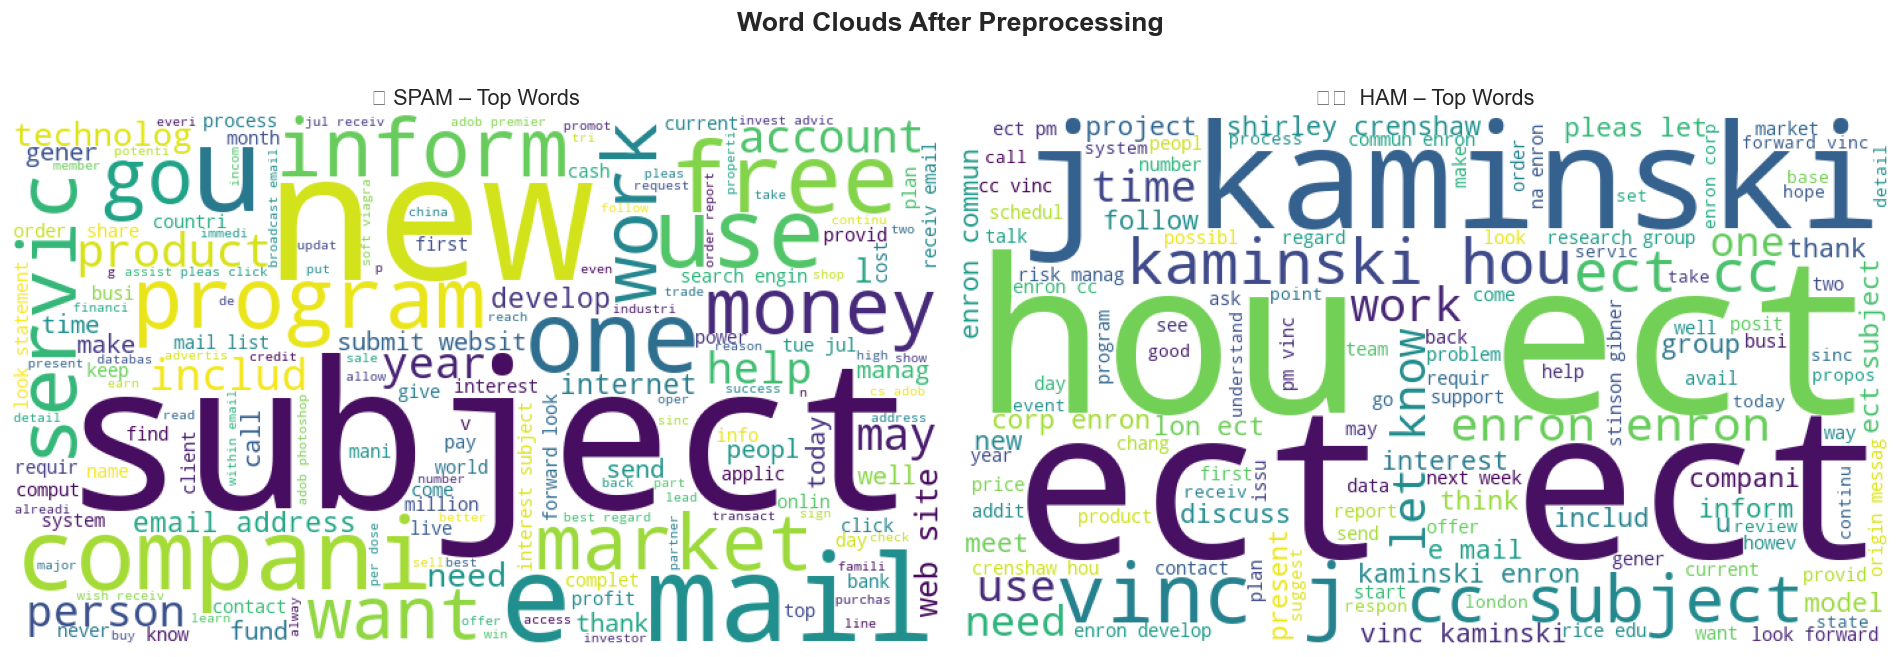

In [57]:
# ── Word Clouds ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds After Preprocessing', fontsize=16, fontweight='bold')

wc = WordCloud(width=700, height=400, min_font_size=10, background_color='white')

# Spam word cloud
spam_text = df[df['target'] == 1]['transformed_text'].str.cat(sep=' ')
axes[0].imshow(wc.generate(spam_text))
axes[0].set_title('🚫 SPAM – Top Words', fontsize=13)
axes[0].axis('off')

# Ham word cloud
ham_text = df[df['target'] == 0]['transformed_text'].str.cat(sep=' ')
axes[1].imshow(wc.generate(ham_text))
axes[1].set_title('✉️  HAM – Top Words', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

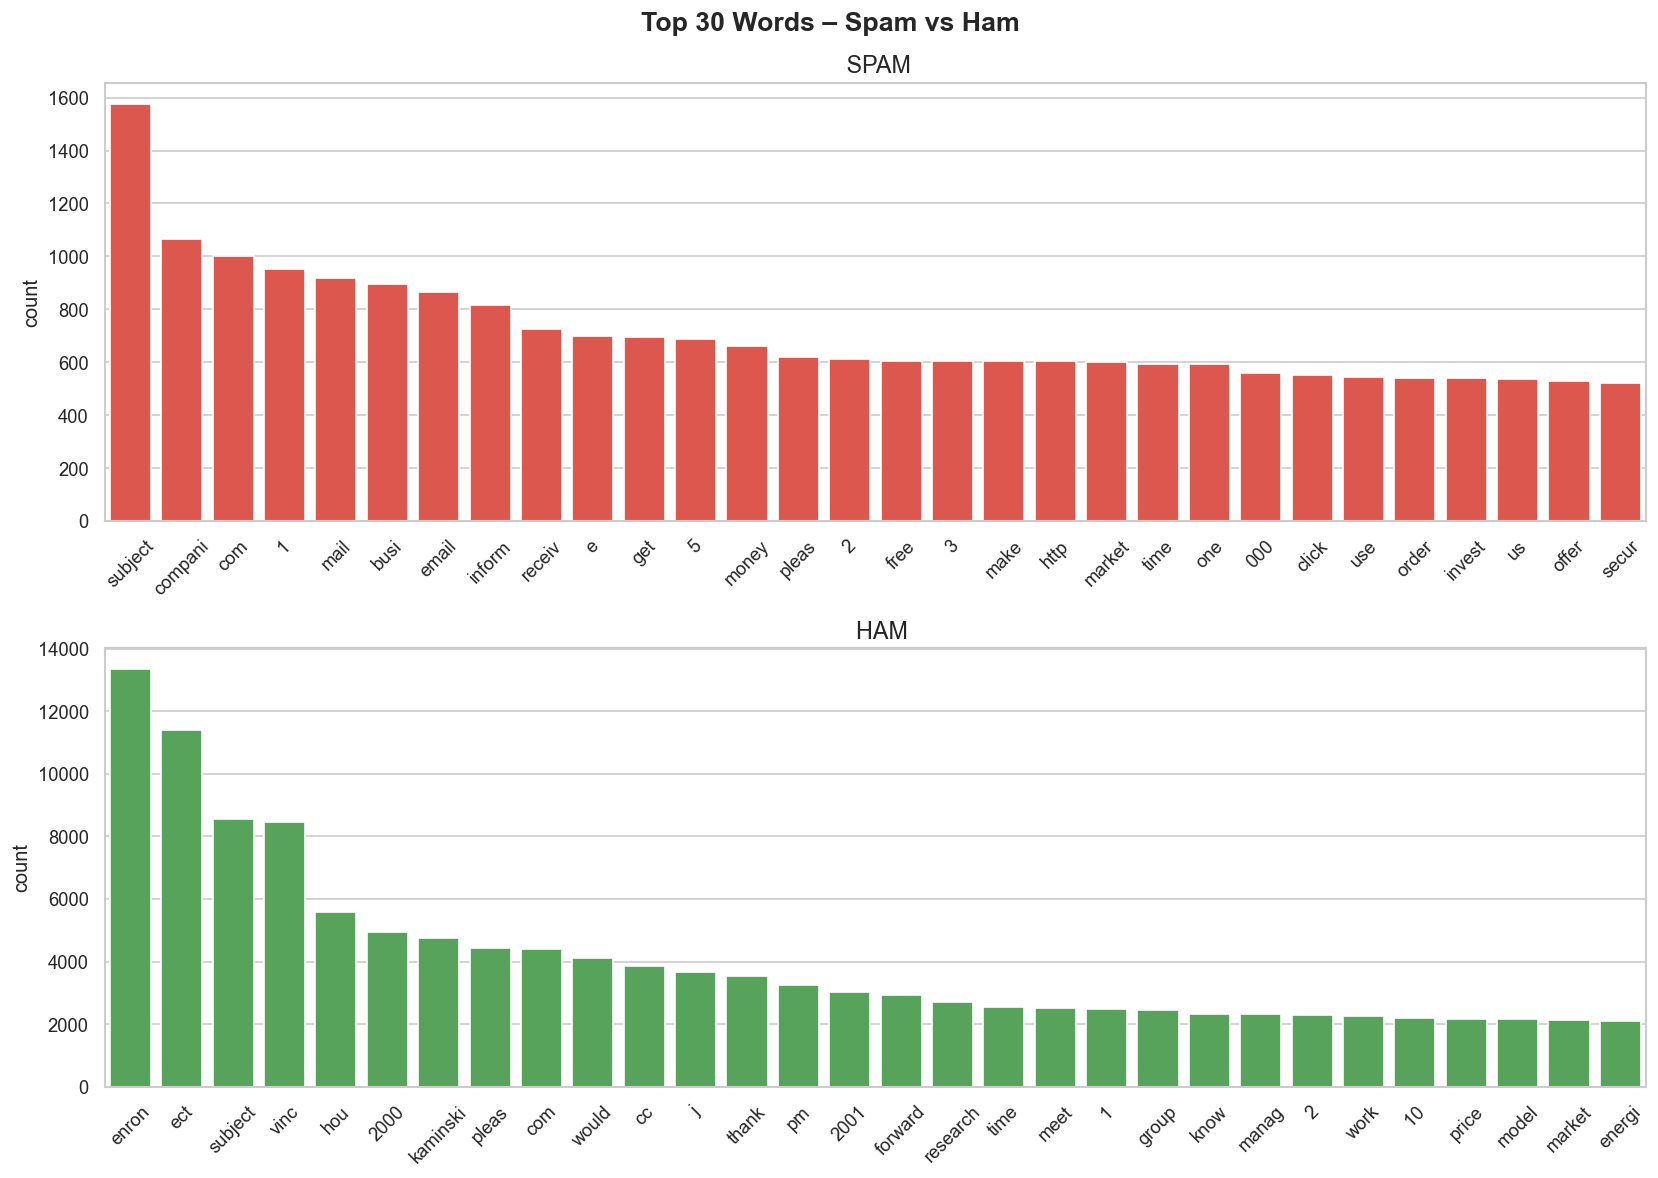

In [58]:
# ── Top 30 words per class ────────────────────────────────────────
def get_top_words(series, n=30):
    words = [word for msg in series.tolist() for word in msg.split()]
    return pd.DataFrame(Counter(words).most_common(n), columns=['word', 'count'])

top_spam = get_top_words(df[df['target'] == 1]['transformed_text'])
top_ham  = get_top_words(df[df['target'] == 0]['transformed_text'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Top 30 Words – Spam vs Ham', fontsize=16, fontweight='bold')

sns.barplot(data=top_spam, x='word', y='count', ax=axes[0], color='#F44336')
axes[0].set_title(' SPAM')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('')

sns.barplot(data=top_ham, x='word', y='count', ax=axes[1], color='#4CAF50')
axes[1].set_title('  HAM')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## 6. Data Splitting & Feature Extraction

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** to convert text into numerical feature vectors. Then we split into training and test sets using an **80/20 split**.

> The TF-IDF vectorizer is fitted **only on the training set** to prevent data leakage.

In [59]:
X = df['transformed_text'].values
y = df['target'].values

# ── Train / test split (80/20) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)

# ── TF-IDF vectorization ──────────────────────────────────────────
tf = TfidfVectorizer(max_features=3000)
X_train_vec = tf.fit_transform(X_train)  # fit + transform on train
X_test_vec  = tf.transform(X_test)       # transform only on test

print(f' Training set  : {X_train_vec.shape[0]} samples, {X_train_vec.shape[1]} features')
print(f' Test set      : {X_test_vec.shape[0]} samples, {X_test_vec.shape[1]} features')
print(f'\nClass balance in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'   {"Ham" if u==0 else "Spam"}: {c} samples ({c/len(y_train)*100:.1f}%)')

 Training set  : 4556 samples, 3000 features
 Test set      : 1139 samples, 3000 features

Class balance in training set:
   Ham: 3462 samples (76.0%)
   Spam: 1094 samples (24.0%)


### 🔄 Handling Class Imbalance with SMOTE
 **SMOTE (Synthetic Minority Over-sampling Technique)** on the training set to create synthetic spam examples, balancing both classes.

> SMOTE is applied **only to the training set** — the test set remains untouched to reflect real-world distribution.

In [60]:
smote = SMOTE(random_state=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train_vec, y_train)

_, counts_before = np.unique(y_train, return_counts=True)
_, counts_after  = np.unique(y_train_sm, return_counts=True)

print('── SMOTE Resampling Results ───────────────────────────')
print(f'  Before SMOTE →  Ham: {counts_before[0]}   | Spam: {counts_before[1]}')
print(f'  After  SMOTE →  Ham: {counts_after[0]}  | Spam: {counts_after[1]}')
print('───────────────────────────────────────────────────────')
print(' Classes are now balanced for training.')

── SMOTE Resampling Results ───────────────────────────
  Before SMOTE →  Ham: 3462   | Spam: 1094
  After  SMOTE →  Ham: 3462  | Spam: 3462
───────────────────────────────────────────────────────
 Classes are now balanced for training.


---
## 7. Model Building & Training



In [61]:
# ── Define all classifiers ────────────────────────────────────────
clfs = {
    'SVC'  : SVC(kernel='sigmoid', gamma=1.0),
     'BNB'  : BernoulliNB(),
    'KNC'  : KNeighborsClassifier(),
    'MNB'  : MultinomialNB(),
    'DTC'  : DecisionTreeClassifier(max_depth=5),
    'LRC'  : LogisticRegression(solver='liblinear', penalty='l1'),
    'RFC'  : RandomForestClassifier(n_estimators=50, random_state=2),

}

def train_classifier(clf, X_tr, y_tr, X_te, y_te):
    """Train a classifier and return accuracy and precision."""
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    return (
        accuracy_score(y_te, y_pred),
        precision_score(y_te, y_pred, zero_division=0)
    )

# ── Train all classifiers and collect scores ──────────────────────
results = []
for name, model in clfs.items():
    # GaussianNB and KNN need dense arrays
    if name in ['KNC']:
        acc, prec = train_classifier(model, X_train_vec.toarray(), y_train,
                                      X_test_vec.toarray(), y_test)
    else:
        acc, prec = train_classifier(model, X_train_vec, y_train, X_test_vec, y_test)
    results.append({'Algorithm': name, 'Accuracy': acc, 'Precision': prec})
    print(f'  ✔ {name:<6}  Accuracy: {acc:.4f}   Precision: {prec:.4f}')

df_results = pd.DataFrame(results).sort_values('Precision', ascending=False)
print('\n All models trained!')

  ✔ SVC     Accuracy: 0.9930   Precision: 0.9926
  ✔ BNB     Accuracy: 0.9464   Precision: 0.8179
  ✔ KNC     Accuracy: 0.9868   Precision: 0.9924
  ✔ MNB     Accuracy: 0.9886   Precision: 0.9888
  ✔ DTC     Accuracy: 0.9210   Precision: 0.7771
  ✔ LRC     Accuracy: 0.9816   Precision: 0.9668
  ✔ RFC     Accuracy: 0.9851   Precision: 0.9813

 All models trained!


In [62]:
# ── Model comparison table ────────────────────────────────────────
print(' Model Comparison (sorted by Precision):')
display(
    df_results.style
    .background_gradient(subset=['Accuracy', 'Precision'], cmap='YlGn')
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}'})
    .set_caption('All classifiers evaluated on the held-out test set')
)

 Model Comparison (sorted by Precision):


,Algorithm,Accuracy,Precision
0,SVC,0.9930,0.9926
2,KNC,0.9868,0.9924
3,MNB,0.9886,0.9888
6,RFC,0.9851,0.9813
5,LRC,0.9816,0.9668
1,BNB,0.9464,0.8179
4,DTC,0.9210,0.7771


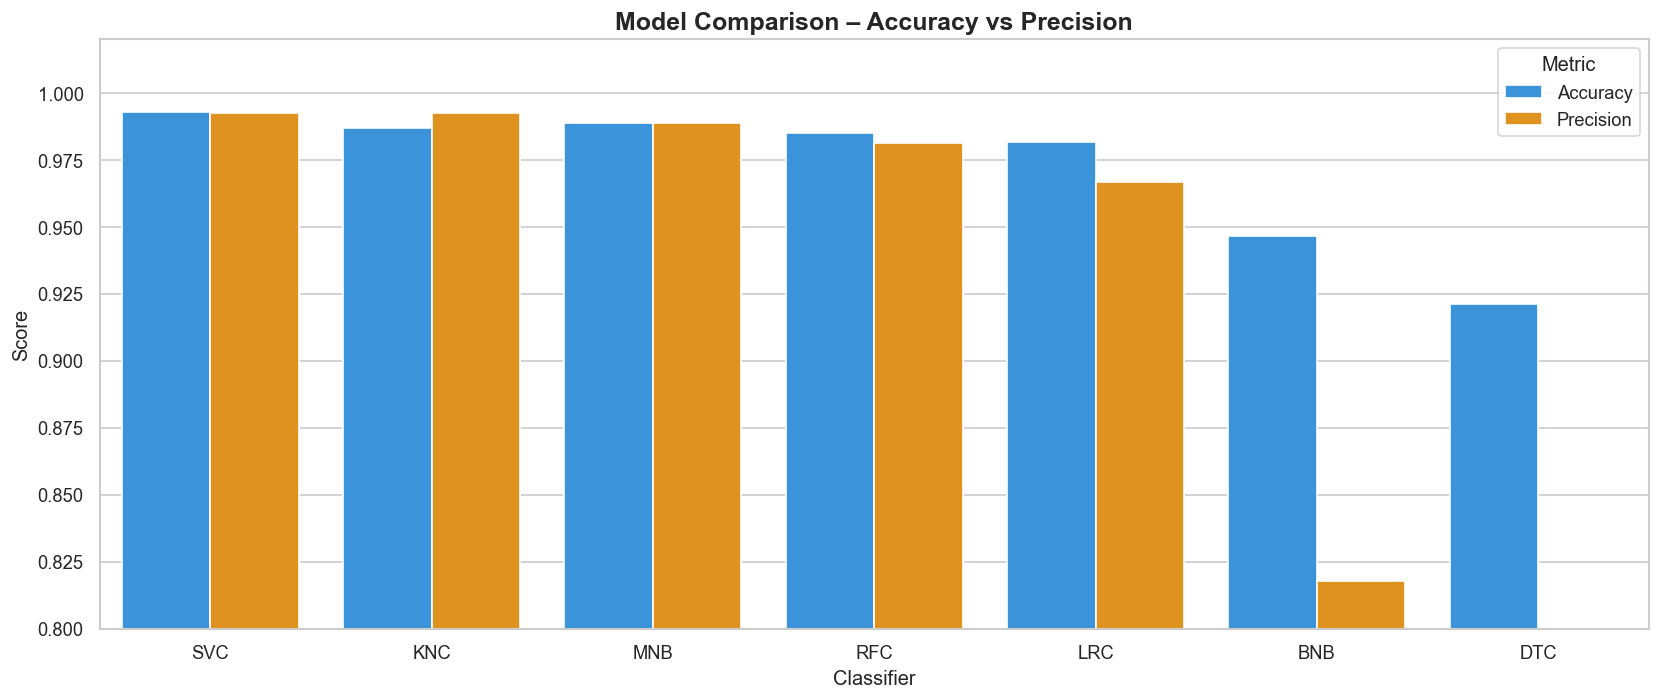


  Best model by Precision: SVC (0.9926)
   → For spam detection, precision matters most (we want to avoid false positives).


In [63]:
# ── Grouped bar chart ─────────────────────────────────────────────
df_melt = pd.melt(df_results, id_vars='Algorithm', value_vars=['Accuracy', 'Precision'])

plt.figure(figsize=(14, 6))
sns.barplot(data=df_melt, x='Algorithm', y='value', hue='variable',
            palette={'Accuracy': '#2196F3', 'Precision': '#FF9800'})
plt.title('Model Comparison – Accuracy vs Precision', fontsize=15, fontweight='bold')
plt.xlabel('Classifier')
plt.ylabel('Score')
plt.ylim(0.8, 1.02)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

best_model_name = df_results.iloc[0]['Algorithm']
best_prec       = df_results.iloc[0]['Precision']
print(f'\n  Best model by Precision: {best_model_name} ({best_prec:.4f})')
print('   → For spam detection, precision matters most (we want to avoid false positives).')

In [64]:
# ── Train final model ─────────────────────────────────────────────
final_model = SVC(probability=True, random_state=2)
final_model.fit(X_train_vec, y_train)

# ── Predict on test set ───────────────────────────────────────────
y_pred_final = final_model.predict(X_test_vec)

print(' Final Model: SVC')
print(f' Test set size: {len(y_test)} samples')
print(f' Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f' Precision: {precision_score(y_test, y_pred_final):.4f}')

 Final Model: SVC
 Test set size: 1139 samples
 Accuracy : 0.9956
 Precision: 1.0000


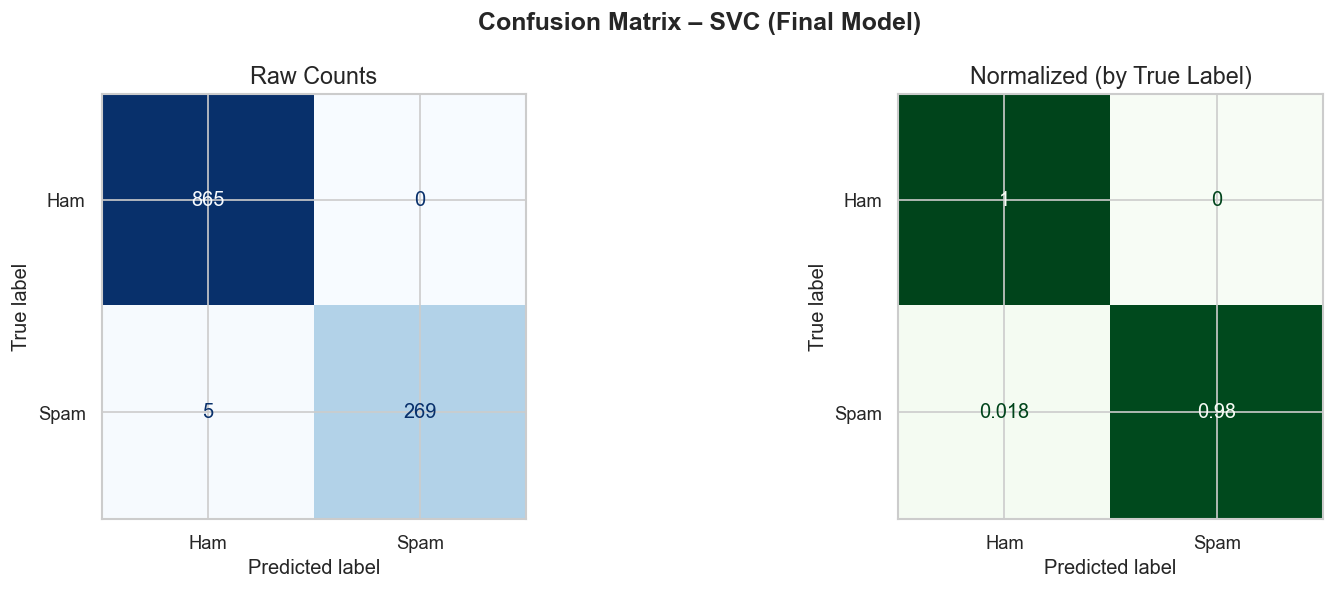


  True Negatives  (Ham → Ham)   : 865
  False Positives (Ham → Spam)  : 0  ← Ham flagged as spam (costly!)
  False Negatives (Spam → Ham)  : 5  ← Spam slipping through
  True Positives  (Spam → Spam) : 269


In [65]:
# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix – SVC (Final Model)', fontsize=15, fontweight='bold')

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts')

# Normalized
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Ham', 'Spam'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Normalized (by True Label)')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\n  True Negatives  (Ham → Ham)   : {tn}')
print(f'  False Positives (Ham → Spam)  : {fp}  ← Ham flagged as spam (costly!)')
print(f'  False Negatives (Spam → Ham)  : {fn}  ← Spam slipping through')
print(f'  True Positives  (Spam → Spam) : {tp}')

In [66]:
# ── Classification Report ─────────────────────────────────────────
print('=' * 55)
print('       CLASSIFICATION REPORT – SVC()')
print('=' * 55)
print(classification_report(y_test, y_pred_final, target_names=['Ham', 'Spam']))
print('=' * 55)


       CLASSIFICATION REPORT – SVC()
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       865
        Spam       1.00      0.98      0.99       274

    accuracy                           1.00      1139
   macro avg       1.00      0.99      0.99      1139
weighted avg       1.00      1.00      1.00      1139



In [67]:
# ── Sample predictions from test set ─────────────────────────────
sample_indices = np.random.RandomState(7).choice(len(X_test), size=10, replace=False)

pred_df = pd.DataFrame({
    'Message'          : [X_test[i] for i in sample_indices],
    'True Label'       : [' Spam' if y_test[i] else '  Ham' for i in sample_indices],
    'Predicted Label'  : [' Spam' if y_pred_final[i] else '  Ham' for i in sample_indices],
    'Correct?'         : ['✅' if y_test[i] == y_pred_final[i] else '❌'
                          for i in sample_indices]
})

print(' Sample Predictions on Test Set:')
display(pred_df.style.set_caption('Sample from held-out test set'))

 Sample Predictions on Test Set:


,Message,True Label,Predicted Label,Correct?
0,subject take advantag offer 24344 copi dvd cd r burner dvd wizard pro technolog advanc method dvd reproduct ever avail fool fli night websit offer outdat inform packag show backup dvd vh cassett use cd r burner go show backup dvd use dvd r dvd rw burner well make qualiti backup person dvd vh cassett creat dvd librari never worri scratch lose dvd dvd wizard pro complet unlik anyth competitor offer fulli guarante order today disappoint limit time 39 95 sold packag much 69 95 limit time offer instant access 39 95 go order copi today email address obtain opt list opt mrsa list purchas code 31212 1 01210 wish unsubscrib list pleas click press send remov previous unsubscrib still receiv messag may email spam abus control center condon spam shape form thank kindli cooper,Spam,Spam,✅
1,subject registr materi nfcf andr almazan chew john freeman geog gau vinc kaminski bob marchesi john martin vojislav maksimov laura stark art warga michael weisbach dear friend attach registr logist inform relat upcom corpor financ confer may 4 5 houston question pleas hesit contact sheridan bob program shape nice howev one us may draft serv small help capac sheridan titman 512 232 2787 titman mail utexa edu bob parrino parrino mail utexa edu dave ikenberri 713 348 5385 daveik rice edu today list firm send repres includ pfizer pacificar cooper industri radioshack pepsi delphi automot microsoft whirlpool enron johnson control airga sara lee dell conoco particp regist detail doc prof david ikenberri jone graduat school manag rice univers 713 348 5385,Ham,Ham,✅
2,subject help dear sir mr mariam abacha wife late nigerian head state gener sani abacha die 8 th june 1998 still activ duti contact view fact great assist likewis develop cordial relationship current within reach sum thirti six million unit state dollar us 36 000 000 cash intend use invest purpos specif countri money came result payback contract deal late husband russian firm countri multi billion dollar ajaokuta steel plant russian partner return husband share us 36 000 000 death lodg late husband secur compani nigeria director right new civilian govern intensifi probe husband financi resourc revok licens allow us financi oil compani view act fast withdraw us 36 000 000 compani vault deposit privat erect secur safe abroad record ever exist concern money neither money traceabl govern document show receiv money russian due current situat countri concern govern attitud toward famili becom quit imposs make use money within thu seek assist transfer money safe bank account consent shall expect contact urgent enabl us discuss detail transact bear mind assist need transfer fund propos commiss 20 total sum expect servic assist urgent respons highli need stop contact correspond forward email zenab ompadec zzn con call son mobil hamza 234 8023137978 use opportun implor exercis utmost indulg keep matter extra ordinarili confidenti ever decis await prompt respons best person regard mr mariam abacha sf net email sponsor jabber world fastest grow real time commun platform im build http www jabber com osdn xim spamassassin sight mail list,Spam,Spam,✅
3,subject thank thank updat vinc tri discuss sever day know busi jaesoo told want base 90 k rather 85 k author offer told would discuss get back glad seen way littl clearli call tomorrow final offer vinc j kaminski 11 07 2000 05 29 pm molli mage hou ect ect cc vinc j kaminski hou ect ect subject thank fyi vinc forward vinc j kaminski hou ect 11 07 2000 05 36 pm jlew kent edu 11 07 2000 07 19 20 vinc j kaminski enron com cc jlew kent edu subject thank dear dr kaminski first would like thank offer enron realli appreci molli talk salari day honest pleas possibl work want work salari next matter bother pleas ignor accept origin offer look forward see soon sincer jaesoo,Ham,Ham,✅
4,subject luigi zingal seminar april 27 rice enron financ seminar particip luigi zingal present paper co author raghuram g rajan entitl great revers 

In [68]:
# ── Live prediction function ──────────────────────────────────────
def predict_sms(message: str) -> str:
    """
    Predict whether a given SMS message is Ham or Spam.
    Applies the same preprocessing pipeline used during training.
    """
    cleaned  = transform_text(message)
    vec      = tf.transform([cleaned])
    result   = final_model.predict(vec)[0]
    label    = ' SPAM' if result == 1 else '  HAM'
    prob     = final_model.predict_proba(vec)[0]
    conf     = prob[result]
    return f'{label}  (confidence: {conf:.2%})'


# ── Test with custom examples ────────────────────────────────────
test_messages = [
    'Congratulations! You have won a FREE iPhone. Click here to claim now!!!',
    'Hey, are we still meeting for lunch tomorrow?',
    'URGENT: Your account has been compromised. Call this number immediately: 080-FREE',
    'Can you pick up some milk on your way home?'
]

print(' Live Predictions:')
print('─' * 70)
for msg in test_messages:
    print(f'  Message  : {msg[:65]}')
    print(f'  Result   : {predict_sms(msg)}')
    print('─' * 70)

 Live Predictions:
──────────────────────────────────────────────────────────────────────
  Message  : Congratulations! You have won a FREE iPhone. Click here to claim 
  Result   :  SPAM  (confidence: 100.00%)
──────────────────────────────────────────────────────────────────────
  Message  : Hey, are we still meeting for lunch tomorrow?
  Result   :   HAM  (confidence: 97.55%)
──────────────────────────────────────────────────────────────────────
  Message  : URGENT: Your account has been compromised. Call this number immed
  Result   :   HAM  (confidence: 44.06%)
──────────────────────────────────────────────────────────────────────
  Message  : Can you pick up some milk on your way home?
  Result   :   HAM  (confidence: 77.87%)
──────────────────────────────────────────────────────────────────────


---
## 💾 10. Model Deployment (Save with Pickle)

We serialize both the **TF-IDF vectorizer** and the **trained model** using Pickle. These files can be loaded later in a Flask/Streamlit app to serve predictions without re-training.

> 📦 **Files saved:**
> - `vectorizer.pkl` — the fitted TF-IDF transformer
> - `model.pkl` — the trained BernoulliNB classifier

In [69]:
# ── Save artifacts ────────────────────────────────────────────────
pickle.dump(tf,          open('vectorizer.pkl', 'wb'))
pickle.dump(final_model, open('model.pkl',      'wb'))

print(' Model artifacts saved:')
print('   vectorizer.pkl  → TfidfVectorizer (max_features=3000)')
print('   model.pkl       →  SVC classifier')

# ── Verify reload works ───────────────────────────────────────────
loaded_vec   = pickle.load(open('vectorizer.pkl', 'rb'))
loaded_model = pickle.load(open('model.pkl',      'rb'))

test_msg  = 'Win a free vacation now! Call us!'
test_pred = loaded_model.predict(loaded_vec.transform([transform_text(test_msg)]))[0]
print(f'\n Reload verification:')
print(f'   Message : "{test_msg}"')
print(f'   Result  : {" SPAM" if test_pred == 1 else "✉️  HAM"}  ')

 Model artifacts saved:
   vectorizer.pkl  → TfidfVectorizer (max_features=3000)
   model.pkl       →  SVC classifier

 Reload verification:
   Message : "Win a free vacation now! Call us!"
   Result  :  SPAM  
